In [ ]:
# CNN/DM dataset
!git clone https://github.com/abisee/cnn-dailymail.git
!cd cnn-dailymail && ./download_cnn_dm.sh

# XSum dataset
!git clone https://github.com/EdinburghNLP/XSum.git
!cd XSum && bash download.sh

# Newsroom dataset (direct download link)
!wget http://www.statmt.org/newsroom/corpus/newsroom.tar.gz
!tar -xvzf newsroom.tar.gz


Cloning into 'cnn-dailymail'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 61 (delta 16), reused 61 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 15.69 MiB | 15.97 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/bin/bash: line 1: ./download_cnn_dm.sh: No such file or directory
Cloning into 'XSum'...
remote: Enumerating objects: 390, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 390 (delta 2), reused 3 (delta 1), pack-reused 384 (from 1)
Receiving objects: 100% (390/390), 10.18 MiB | 21.24 MiB/s, done.
Resolving deltas: 100% (194/194), done.
bash: download.sh: No such file or directory
--2025-02-05 07:40:11--  http://www.statmt.org/newsroom/corpus/newsroom.tar.gz
Resolving www.statmt.org (www.statmt.org)... 129.215.32.28
Connecting to www.statmt.org (www.statmt.org)|129.215.32.28|:80... connect

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')

def preprocess_text(text):
    sentences = sent_tokenize(text)  # Split the text into sentences
    return sentences

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define ExtractorAgent class
class ExtractorAgent(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads):
        super(ExtractorAgent, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads)
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        attn_output, attn_output_weights = self.attn(x, x, x)
        output = self.fc(attn_output)
        return output

# Instantiate the Extractor Agent
input_dim = 768  # Example input dimension (can vary depending on your input)
output_dim = 1  # Example output dimension (e.g., binary classification or sentence selection)
num_heads = 8  # Number of attention heads in multi-head attention
extractor = ExtractorAgent(input_dim, output_dim, num_heads)

# Initialize the optimizer
optimizer = torch.optim.Adam(extractor.parameters(), lr=0.001)

# Training function
def train_extractor(agent, data, target):
    agent.train()
    optimizer.zero_grad()
    output = agent(data)  # Forward pass
    loss = F.mse_loss(output, target)  # Sample loss function (can be modified based on your task)
    loss.backward()
    optimizer.step()
    return loss.item()


In [ ]:
class CompressorAgent(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CompressorAgent, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        compressed_output = self.fc(x)
        return compressed_output

class DualAgentModel(nn.Module):
    def __init__(self, extractor, compressor):
        super(DualAgentModel, self).__init__()
        self.extractor = extractor
        self.compressor = compressor

    def forward(self, x):
        extracted_sentences = self.extractor(x)
        compressed_output = self.compressor(extracted_sentences)
        return compressed_output



In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=992eb71fa5d14bf4f47da419d66ed43aa569cad9d42461b901a60348b80754ed
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [ ]:
from rouge_score import rouge_scorer

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = {}
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        for key in score:
            if key not in scores:
                scores[key] = []
            scores[key].append(score[key].fmeasure)

    avg_scores = {key: sum(val) / len(val) for key, val in scores.items()}
    return avg_scores

import matplotlib.pyplot as plt

def plot_scores(scores):
    labels = list(scores.keys())
    values = list(scores.values())

    plt.bar(labels, values)
    plt.xlabel('ROUGE Scores')
    plt.ylabel('F-Measure')
    plt.show()


In [ ]:
def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = {}

    # Iterate through each prediction and reference
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        for key in score:
            if key not in scores:
                scores[key] = []
            scores[key].append(score[key].fmeasure)

    # Compute average scores
    avg_scores = {key: sum(val) / len(val) for key, val in scores.items()}
    return avg_scores


In [ ]:
# Example predictions and references
predictions = ["The quick brown fox jumps over the lazy dog."]
references = ["A quick brown fox jumps over a lazy dog."]

# Calculate ROUGE scores
rouge_scores = compute_rouge(predictions, references)

# Print the average ROUGE scores
print("ROUGE Scores:", rouge_scores)


ROUGE Scores: {'rouge1': 0.7777777777777778, 'rouge2': 0.625, 'rougeL': 0.7777777777777778}


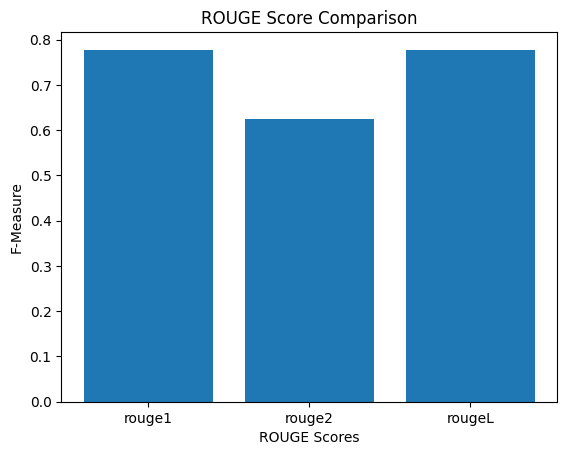

In [ ]:
import matplotlib.pyplot as plt

def plot_scores(scores):
    labels = list(scores.keys())
    values = list(scores.values())

    plt.bar(labels, values)
    plt.xlabel('ROUGE Scores')
    plt.ylabel('F-Measure')
    plt.title('ROUGE Score Comparison')
    plt.show()

# Plot the ROUGE scores
plot_scores(rouge_scores)
